In [3]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

# *Exploración y descripción de la base de datos*

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
ECG_DIR = Path("ECGDataDenoised")
archivos = sorted(ECG_DIR.glob("*.csv"))

print("Número de archivos encontrados:", len(archivos))

DIAG_DIR=Path("Diagnostics.xlsx")

Número de archivos encontrados: 10646


In [5]:
diag = pd.read_excel(DIAG_DIR)

print("Dimensión de Diagnostics:", diag.shape)
display(diag.head())
print("\nColumnas:")
print(diag.columns.tolist())

Dimensión de Diagnostics: (10646, 16)


,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354



Columnas:
['FileName', 'Rhythm', 'Beat', 'PatientAge', 'Gender', 'VentricularRate', 'AtrialRate', 'QRSDuration', 'QTInterval', 'QTCorrected', 'RAxis', 'TAxis', 'QRSCount', 'QOnset', 'QOffset', 'TOffset']


In [6]:
ecg = pd.read_csv(archivos[0])


fs = 500  

n_muestras = ecg.shape[0]
n_canales = ecg.shape[1]
duracion = n_muestras / fs

print("Número de registros:", len(archivos))
print("Número de canales:", n_canales)
print("Derivaciones:", ecg.columns.tolist())
print("Frecuencia de muestreo:", fs, "Hz")
print("Número de muestras:", n_muestras)
print("Duración:", duracion, "segundos")

Número de registros: 10646
Número de canales: 12
Derivaciones: ['-165.33', '-358.97', '-121.71', '270.25', '-28.869', '-231.16', '448.39', '636.52', '618.45', '-7.8987', '-315.16', '-570.84']
Frecuencia de muestreo: 500 Hz
Número de muestras: 4999
Duración: 9.998 segundos


# *Visualización y caracterización de las señales*

In [7]:
# Se seleccionan las aritmias de fibrilación auricular (AFIB) y taquicardia sinusal (ST), siempre que ambas estén presentes en tus datos.
afib = diag[diag["Rhythm"] == "AFIB"]
st = diag[diag["Rhythm"] == "ST"]

print("Registros AFIB:", len(afib))
print("Registros ST:", len(st))

# Seleccionar un registro de cada grupo

archivo_afib = ECG_DIR / (str(afib.iloc[0]["FileName"]) + ".csv")
archivo_st = ECG_DIR / (str(st.iloc[0]["FileName"]) + ".csv")

ecg_afib = pd.read_csv(archivo_afib)
ecg_st = pd.read_csv(archivo_st)

Registros AFIB: 1780
Registros ST: 1568


In [8]:
derivaciones = [
    "I", "II", "III",
    "aVR", "aVL", "aVF",
    "V1", "V2", "V3",
    "V4", "V5", "V6"
]

ecg_afib = pd.read_csv(
    archivo_afib,
    header=None,
    names=derivaciones
)

ecg_st = pd.read_csv(
    archivo_st,
    header=None,
    names=derivaciones
)

print(ecg_afib.shape)
print(ecg_st.shape)



(5000, 12)
(5000, 12)


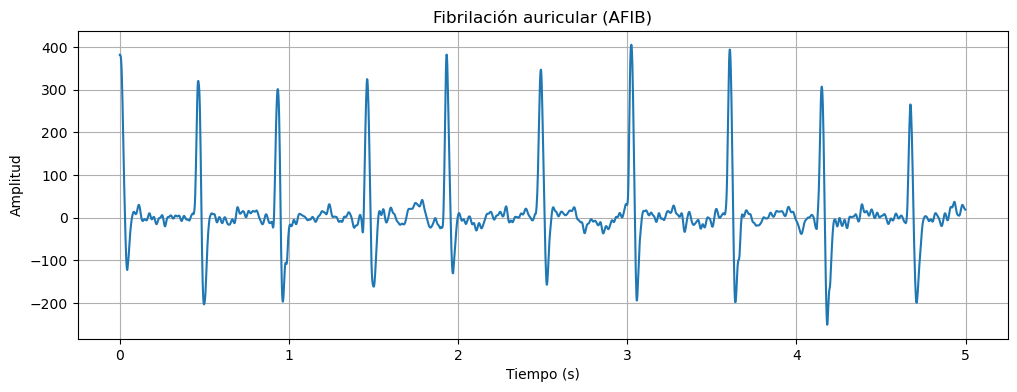

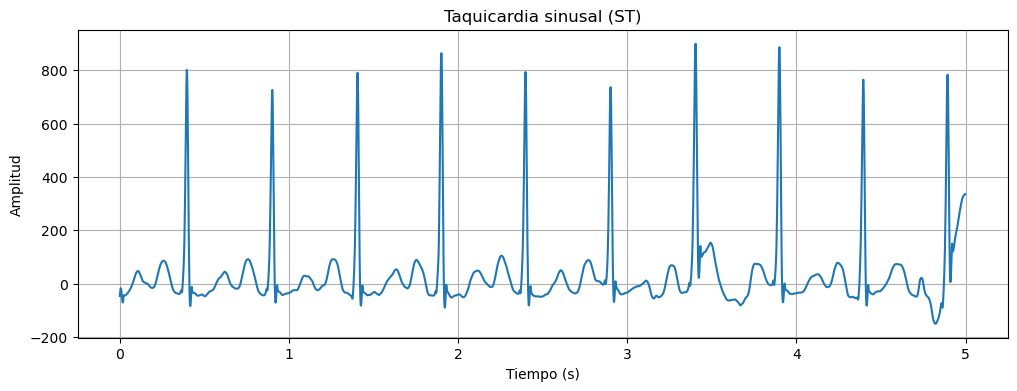

In [9]:
fs = 500

n = 5 * fs

t = np.arange(n) / fs

plt.figure(figsize=(12, 4))

plt.plot(t, ecg_afib["II"].iloc[:n])

plt.title("Fibrilación auricular (AFIB)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

plt.show()


plt.figure(figsize=(12, 4))

plt.plot(t, ecg_st["II"].iloc[:n])

plt.title("Taquicardia sinusal (ST)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()

plt.show()

# *Análisis estadístico entre arritmias*

In [10]:
from scipy.signal import find_peaks

def caracteristicas(archivo):

    ecg = pd.read_csv(archivo, header=None, names=derivaciones)

    señal = ecg["II"].to_numpy()

    media = np.mean(señal)

    desviacion = np.std(señal, ddof=1)

    maximo = np.max(señal)

    minimo = np.min(señal)

    rms = np.sqrt(np.mean(señal**2))

    # Detección preliminar de picos R
    picos, _ = find_peaks(
        señal,
        distance=int(0.3 * fs),
        prominence=np.std(señal)
    )

    if len(picos) > 1:

        intervalos_rr = np.diff(picos) / fs

        fc = 60 / np.mean(intervalos_rr)

    else:

        fc = np.nan

    return [media, desviacion, maximo, minimo, fc, rms]

resultados = []

for grupo, datos in [("AFIB", afib), ("ST", st)]:

    for nombre in datos["FileName"]:

        archivo = ECG_DIR / (str(nombre) + ".csv")

        if archivo.exists():

            valores = caracteristicas(archivo)

            resultados.append([nombre, grupo] + valores)


columnas = [
    "Archivo",
    "Arritmia",
    "Media",
    "Desviacion",
    "Maximo",
    "Minimo",
    "FC",
    "RMS"
]

df = pd.DataFrame(resultados, columns=columnas)

display(df.groupby("Arritmia").head(5))



,Archivo,Arritmia,Media,Desviacion,Maximo,Minimo,FC,RMS
0,MUSE_20180113_171327_27000,AFIB,8.630897,77.751527,450.15,-250.600,117.060481,78.221373
1,MUSE_20180114_075026_69000,AFIB,21.241662,77.967253,547.99,-112.970,97.959184,80.801516
2,MUSE_20180113_133901_16000,AFIB,6.864541,41.587275,313.92,-82.523,72.131148,42.145907
3,MUSE_20180116_123940_90000,AFIB,16.180496,103.870271,791.94,-364.620,79.348932,105.112719
4,MUSE_20180114_075003_61000,AFIB,12.833575,103.896434,664.12,-866.820,83.870968,104.675741
1780,MUSE_20180113_135023_96000,ST,31.140003,134.247571,899.13,-150.090,120.253165,137.798786
1781,MUSE_20180116_170254_89000,ST,32.345881,104.066523,644.04,-161.380,109.771847,108.967570
1782,MUSE_20180114_121405_34000,ST,38.107777,182.045786,1137.40,-291.280,106.649937,185.973768
1783,MUSE_20180119_173922_99000,ST,24.534453,122.754872,1241.20,-100.020,104.916684,125.170621
1784,MUSE_20180113_131104_16000,ST,13.607421,99.691744,530.97,-128.310,112.805515,100.606253


Media                                                Desviacion  \
               mean        std     median         min         max        mean   
Arritmia                                                                        
AFIB      24.286408  23.499411  22.962291 -104.954054  121.629528  129.024313   
ST        26.323533  28.678524  26.072863 -192.029353  190.222761  157.013477   

                                                        ...          FC  \
                std      median        min         max  ...        mean   
Arritmia                                                ...               
AFIB      63.824853  115.149959  19.868157  521.266588  ...   98.233304   
ST        73.952281  142.735965  25.519295  660.396281  ...  112.465202   

                                                               RMS             \
                std      median        min         max        mean        std   
Arritmia                                                                        
AFIB      22.995219   94.956746  39.037085  169.526999  132.401603  65.790895   
ST        11.374197  109.009299  73.775989  175.219024  160.551587  76.514335   

                                             
              median        min         max  
Arritmia                                     
AFIB      118.240349  19.866734  535.217950  
ST        145.141711  25.543124  687.685463  

[2 rows x 30 columns]

<Figure size 700x400 with 0 Axes>

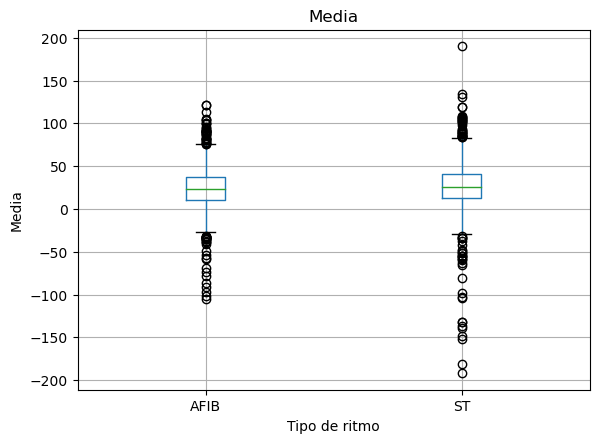

<Figure size 700x400 with 0 Axes>

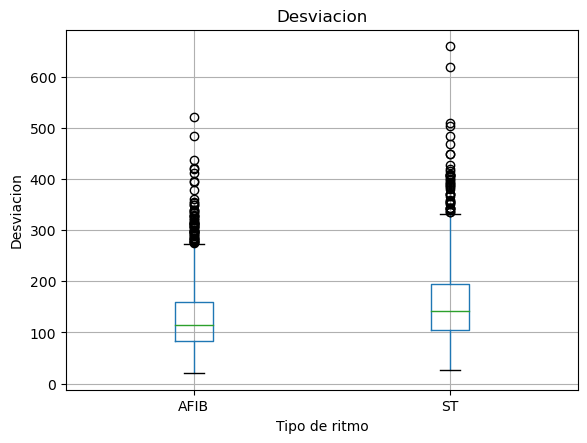

<Figure size 700x400 with 0 Axes>

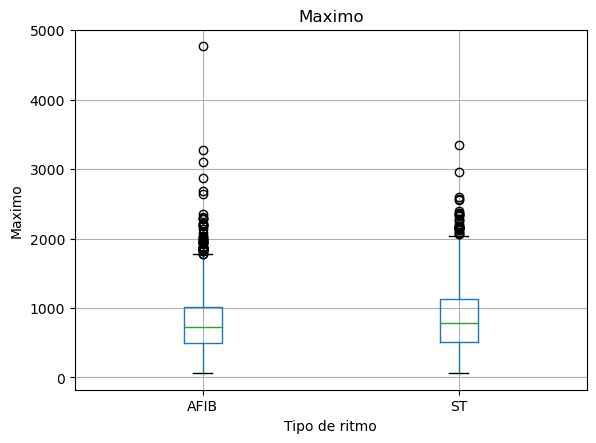

<Figure size 700x400 with 0 Axes>

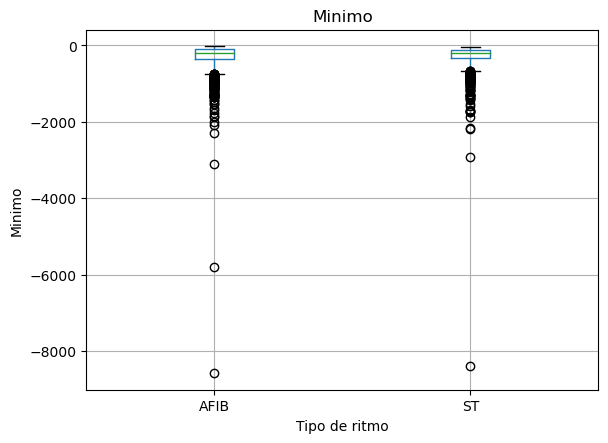

<Figure size 700x400 with 0 Axes>

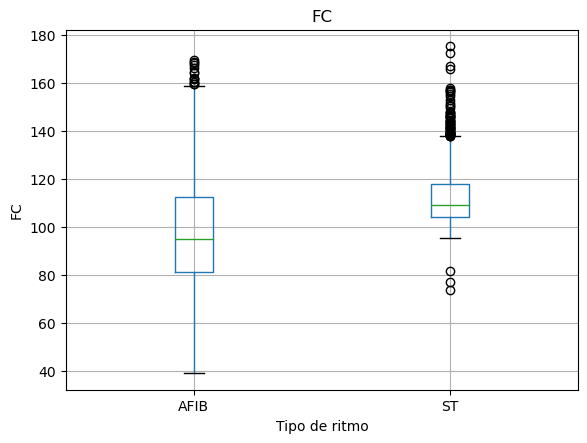

<Figure size 700x400 with 0 Axes>

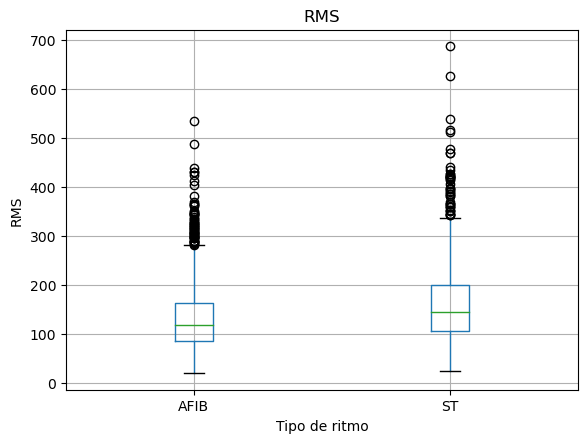

In [11]:
variables = [
    "Media",
    "Desviacion",
    "Maximo",
    "Minimo",
    "FC",
    "RMS"
]

resumen = df.groupby("Arritmia")[variables].agg(
    ["mean", "std", "median", "min", "max"]
)

display(resumen)

for variable in variables:

    plt.figure(figsize=(7, 4))

    df.boxplot(
        column=variable,
        by="Arritmia"
    )

    plt.title(variable)
    plt.suptitle("")
    plt.xlabel("Tipo de ritmo")
    plt.ylabel(variable)

    plt.show()

Hipótesis nula (H₀): no existen diferencias en la característica analizada entre los registros con fibrilación auricular y los registros con taquicardia sinusal.

Hipótesis alternativa (H₁): existen diferencias en la característica analizada entre ambos grupos.

In [12]:
from scipy.stats import shapiro, levene

for variable in variables:

    grupo1 = df[df["Arritmia"] == "AFIB"][variable].dropna()
    grupo2 = df[df["Arritmia"] == "ST"][variable].dropna()

    print("\nVariable:", variable)

    if len(grupo1) >= 3 and len(grupo2) >= 3:

        p1 = shapiro(grupo1).pvalue
        p2 = shapiro(grupo2).pvalue

        print("Shapiro AFIB:", p1)
        print("Shapiro ST:", p2)

        p_levene = levene(grupo1, grupo2).pvalue

        print("Levene:", p_levene)


Variable: Media
Shapiro AFIB: 2.874743111188445e-20
Shapiro ST: 1.2283191861572798e-30
Levene: 0.00012398539545236284

Variable: Desviacion
Shapiro AFIB: 1.13119631640929e-31
Shapiro ST: 1.9017826949298195e-29
Levene: 9.040165994597311e-06

Variable: Maximo
Shapiro AFIB: 5.2674947580121195e-30
Shapiro ST: 6.65336293650751e-22
Levene: 0.00016058572024042455

Variable: Minimo
Shapiro AFIB: 0.0
Shapiro ST: 0.0
Levene: 0.010605179066609828

Variable: FC
Shapiro AFIB: 7.649269334778378e-17
Shapiro ST: 2.2465650844394676e-34
Levene: 1.916475766556754e-116

Variable: RMS
Shapiro AFIB: 1.5823703263622374e-31
Shapiro ST: 8.972257609543901e-30
Levene: 1.0321917888249865e-05


In [13]:

archivos_afib = set(afib["FileName"])
archivos_st = set(st["FileName"])

comunes = archivos_afib.intersection(archivos_st)

print(
    "Archivos presentes en ambos grupos:",
    len(comunes)
)


Archivos presentes en ambos grupos: 0


In [14]:
from scipy.stats import ttest_ind, mannwhitneyu

resultados_pruebas = []

for variable in variables:
    grupo1 = df[df["Arritmia"] == "AFIB"][variable].dropna()
    grupo2 = df[df["Arritmia"] == "ST"][variable].dropna()

    if len(grupo1) < 3 or len(grupo2) < 3:
        continue

    # Prueba de normalidad
    p1 = shapiro(grupo1).pvalue
    p2 = shapiro(grupo2).pvalue

    # Prueba de homocedasticidad
    p_levene = levene(grupo1, grupo2).pvalue

    # Selección de la prueba estadística
    if p1 > 0.05 and p2 > 0.05 and p_levene > 0.05:

        prueba = "t de Student"

        estadistico, p = ttest_ind(
            grupo1,
            grupo2,
            equal_var=True
        )

    else:

        prueba = "Mann-Whitney"

        estadistico, p = mannwhitneyu(
            grupo1,
            grupo2,
            alternative="two-sided"
        )
    decision = (
        "Rechazar H0"
        if p < 0.05
        else "No rechazar H0"
    )

    resultados_pruebas.append([
        variable,
        prueba,
        estadistico,
        p,
        decision
    ])

tabla_pruebas = pd.DataFrame(
    resultados_pruebas,
    columns=[
        "Variable",
        "Prueba",
        "Estadístico",
        "p-valor",
        "Decisión"
    ]
)

display(tabla_pruebas)

,Variable,Prueba,Estadístico,p-valor,Decisión
0,Media,Mann-Whitney,1297200.0,4.269913e-04,Rechazar H0
1,Desviacion,Mann-Whitney,1049159.0,2.301105e-35,Rechazar H0
2,Maximo,Mann-Whitney,1286645.5,9.580237e-05,Rechazar H0
3,Minimo,Mann-Whitney,1484816.5,1.376665e-03,Rechazar H0
4,FC,Mann-Whitney,744694.5,2.829111e-120,Rechazar H0
5,RMS,Mann-Whitney,1059891.0,2.605043e-33,Rechazar H0


El respectivo análisis, con la interpretación de los resultados y reporte de cada prueba estadistica se encuentra en el informe anexo.

# *Interpretación de resultados*

In [18]:
alpha = 0.05

def formato_p(p):
    if p < 0.001:
        return "< 0.001"
    return f"{p:.4f}"

for _, fila in tabla_pruebas.iterrows():

    variable = fila["Variable"]
    prueba = fila["Prueba"]
    estadistico = fila["Estadístico"]
    p = fila["p-valor"]
    decision = fila["Decisión"]

    print('\n')
    print(f"Característica: {variable}")
    print(f"Prueba utilizada: {prueba}")
    print("H0: no existen diferencias estadísticamente significativas entre AFIB y ST.")
    print("H1: existen diferencias estadísticamente significativas entre AFIB y ST.")
    print(f"Nivel de significancia: α = {alpha}")
    print(f"Estadístico de prueba: {estadistico:.4f}")
    print(f"p-valor: {formato_p(p)}")
    print(f"Decisión: {decision}")

    if p < alpha:
        print(
            f"Interpretación: para {variable}, el resultado proporciona "
            "evidencia estadísticamente significativa de una diferencia "
            "entre los registros de AFIB y ST."
        )
    else:
        print(
            f"Interpretación: para {variable}, no se obtiene evidencia "
            "estadísticamente significativa de una diferencia entre los "
            "registros de AFIB y ST."
        )



Característica: Media
Prueba utilizada: Mann-Whitney
H0: no existen diferencias estadísticamente significativas entre AFIB y ST.
H1: existen diferencias estadísticamente significativas entre AFIB y ST.
Nivel de significancia: α = 0.05
Estadístico de prueba: 1297200.0000
p-valor: < 0.001
Decisión: Rechazar H0
Interpretación: para Media, el resultado proporciona evidencia estadísticamente significativa de una diferencia entre los registros de AFIB y ST.


Característica: Desviacion
Prueba utilizada: Mann-Whitney
H0: no existen diferencias estadísticamente significativas entre AFIB y ST.
H1: existen diferencias estadísticamente significativas entre AFIB y ST.
Nivel de significancia: α = 0.05
Estadístico de prueba: 1049159.0000
p-valor: < 0.001
Decisión: Rechazar H0
Interpretación: para Desviacion, el resultado proporciona evidencia estadísticamente significativa de una diferencia entre los registros de AFIB y ST.


Característica: Maximo
Prueba utilizada: Mann-Whitney
H0: no existen dif